<a href="https://colab.research.google.com/github/anniiexp/MAT422/blob/main/2_3_Joint_Distributions_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 - Section 2.3: Joint Distributions, Dependence, and Sampling

## Topics:


*   Joint Probability Distributions
*   Correlation and Dependence
*   Random Samples






In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 2.3.1 Joint Distributions

A joint probability distribution describes the probabilities of 2 random variables are to occur together. For example, if one variable whether it rains and another records whether someone carries an umbrella, the joint distribution gives the probability of each combination. Such as rain with an umbrella or no rain without one.

Let $X = 1$ mean it rains, and $Y = 1$ mean someone carries an umbrella. A value of 0 means the event does not happen.

In [12]:
# Rows: X = no rain, rain
# Columns: Y = no umbrella, umbrella

joint = np.array([
    [0.50, 0.10],
    [0.05, 0.35]
])

print("Joint distribution:\n", joint)
print("Total probability:", joint.sum())
print("P(rain and umbrella):", joint[1, 1])
print("P(rain):", joint[1].sum())

Joint distribution:
 [[0.5  0.1 ]
 [0.05 0.35]]
Total probability: 1.0
P(rain and umbrella): 0.35
P(rain): 0.39999999999999997


Each entry gives the probability of both outcomes happening together. There is a 35% change that it rains and the person carries an umbrella. Adding the rain row gives 0.40, so the overall probability of is 40%. All four entires add to 1 because they cover every possible combination.

Let $X = 1$ mean first flip is heads, and let $Y$ be the total nnumber of heads in both flips.

In [13]:
# Rows: X = 0, 1
# Columns: Y = 0, 1, 2
joint = np.array([
    [0.25, 0.25, 0.00],
    [0.00, 0.25, 0.25]
])

print("Joint distribution:\n", joint)
print("Total probability:", joint.sum())
print("P(first flip is heads and total heads is 2):", joint[1, 2])
print("P(total heads is 2):", joint[:, 2].sum())

Joint distribution:
 [[0.25 0.25 0.  ]
 [0.   0.25 0.25]]
Total probability: 1.0
P(first flip is heads and total heads is 2): 0.25
P(total heads is 2): 0.25


Here, each of the four outcomes-TT, TH, HT, and HH has a probability of 0.25. The value in the position is 0.25 because only HH has a heads on the first flip and 2 heads in total. A zero in the table marks an impossible combination: if the first flip is tails, the total cannot be 2 heads.

# 2.3.2 Correlation and Dependence

Two variables are dependent when knowing one tells us something about the other. Correlation tells how strongly the variables tend to increase or decrease together in a stright-line pattern. A correlation near 1 indicated a strong positive linear relationship, while one near 0 indicated little linear relationship. A correlation of 0 does not always mean the variables are independent.

Here $X$ is a set of random values. The variable y_independent is calculated from $X$ with some random noise, while y_independent is generated separately.

Correlation with dependent Y: 0.9593295725102057
Correlation with independent Y: -0.04669007219759289


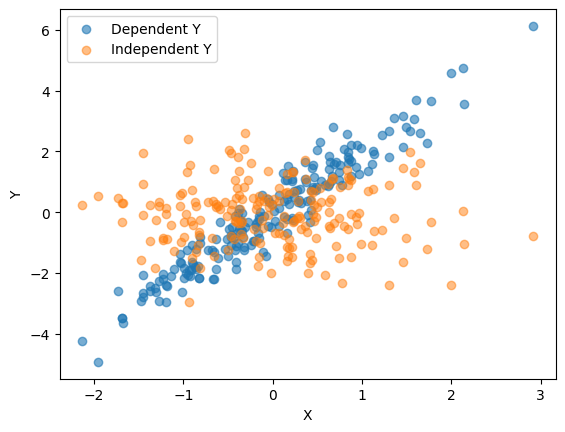

In [14]:
rng = np.random.default_rng(42)

x = rng.normal(0, 1, 200)
y_dependent = 2 * x + rng.normal(0, 0.5, 200)
y_independent = rng.normal(0, 1, 200)

print("Correlation with dependent Y:",
      np.corrcoef(x, y_dependent)[0, 1])
print("Correlation with independent Y:",
      np.corrcoef(x, y_independent)[0, 1])

plt.scatter(x, y_dependent, alpha=0.6, label="Dependent Y")
plt.scatter(x, y_independent, alpha=0.5, label="Independent Y")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In the example above, the dependent points tend to follow an upward line. So their correlation is high and positive. The independent points are more scattered, and their correlations is closer to 0 because they were generated separately from $X$. The printed values confirm the difference shown in the plot.

# 2.3.3 Random Samples

A random sample is a group of observations drawn from a population in accordance to a probability rule. Different samples usually contain different values, so a statistic such as the sample mean will also change from sample to sample. Taking repeated random samples lets us see how much that statistic varies on each run.

In the example below, the population follows an exponential distribution with mean 2. We can draw the 1,000 independent samples of size 10 and 1,000 samples of size 50, and compare their sample means.

Population mean: 2.0
Mean of size-10 sample means: 1.9785068504806358
Mean of size-50 sample means: 2.0070102408541106
SD of size-10 sample means: 0.6231829672099002
SD of size-50 sample means: 0.28382841919827645


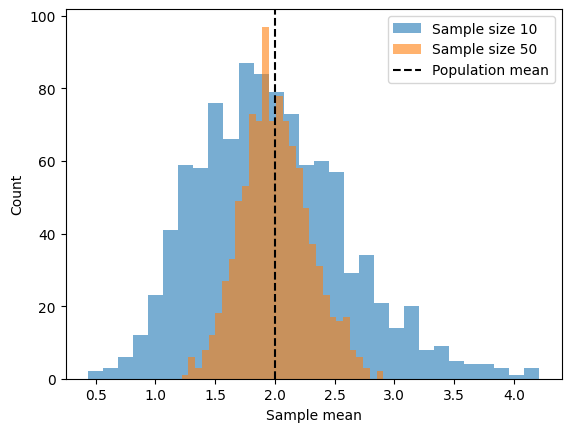

In [15]:
rng = np.random.default_rng(42)
population_mean = 2.0
number_of_samples = 1000

means_10 = []
means_50 = []

for i in range(number_of_samples):
  sample_10 = rng.exponential(scale=population_mean, size=10)
  sample_50 = rng.exponential(scale=population_mean, size=50)

  means_10.append(sample_10.mean())
  means_50.append(sample_50.mean())

means_10 = np.array(means_10)
means_50 = np.array(means_50)

print("Population mean:", population_mean)
print("Mean of size-10 sample means:", means_10.mean())
print("Mean of size-50 sample means:", means_50.mean())
print("SD of size-10 sample means:", means_10.std())
print("SD of size-50 sample means:", means_50.std())

plt.hist(means_10, bins=30, alpha=0.6, label="Sample size 10")
plt.hist(means_50, bins=30, alpha=0.6, label="Sample size 50")
plt.axvline(population_mean, color="black", linestyle="--",
            label="Population mean")
plt.xlabel("Sample mean")
plt.ylabel("Count")
plt.legend()
plt.show()

The average of the sample means should be close to the population mean of 2 for both sample sizes. Although, the means from samples of 50 are less spread out then those of samples of 10. Which shows in both the printed standard deviations and the histogram. This shows that the random larger samples tend to give more consistent estimates of the population mean than the smaller sample sizes.

# Reflection



*   Joint probability distributions: Used rain and umbrella choices and 2 coin flips to show the probabilities of 2 outcomes occuring together. Checked that each joint distribution summed to 1 and found probabilites for individual outcomes by adding rows or columns.
*   Correlation and dependence: Compared variables with a positive linear relationship to variables generated independently. The printed correlations and scatter plot showed the difference. Also used $Y = X^2$ to see that 2 variables can be dependent even when their correlation is around zero.
*   Random samples: Drew repeated from an exponential distribution and calculated their means. Both sets of sample means were centered near the population mean of 2, but samples size 50 produced less variation then sample size 10. This showed larger samples can give more consistent estimates.




